In [32]:
from scvi.module import VAE
from scvi import REGISTRY_KEYS
from scvi.module.base import LossOutput
from scvi.train import TrainingPlan
from torch.distributions import Normal, kl_divergence as kl
import torch.nn as nn
import torch

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import numpy as np
from anndata import AnnData
import scanpy as sc

from scvi.data import AnnDataManager
from scvi.data.fields import (
    LayerField,
    CategoricalObsField,
    NumericalObsField,
    CategoricalJointObsField,
    NumericalJointObsField,
)
from scvi.model.base import BaseModelClass, UnsupervisedTrainingMixin, VAEMixin

from src.model.data_utils import (
    load_data,
    build_metacells,
)

In [23]:
class MixturePriorVAE(VAE):
    """scVI VAE with a Gaussian-mixture prior in latent space instead of N(0, I)."""

    def __init__(self, *args, n_components=None, trainable_means=True,
                 trainable_sigma=False, init_sigma=1.0, means_seperation=2.0,
                 component_key="cluster_idx", **kwargs):
        super().__init__(*args, **kwargs)
        self.component_key = component_key  # registered obs field with the cluster/condition id

        means_active = torch.zeros(n_components, self.n_latent)
        nn.init.orthogonal_(means_active)
        means_active = means_active * self.n_latent**0.5 * means_seperation
        self.means_active = nn.Parameter(means_active, requires_grad=trainable_means)

        self.log_sigma = nn.Parameter(
            torch.full((n_components,), float(np.log(init_sigma))), requires_grad=trainable_sigma
        ) if trainable_sigma else None

    def loss(self, tensors, inference_outputs, generative_outputs, kl_weight=1.0):
        component_idx = tensors[self.component_key].long().squeeze(-1)
        qz = inference_outputs["qz"]  # variational posterior q(z|x)

        mean_p = self.means_active[component_idx]
        sigma_p = (
            torch.exp(self.log_sigma[component_idx]) if self.log_sigma is not None
            else torch.ones_like(mean_p[:, 0])
        )
        pz = Normal(mean_p, sigma_p.unsqueeze(-1).expand_as(mean_p))

        kl_z = kl(qz, pz).sum(dim=-1)

        # scVI's own reconstruction loss: -log p(x | z) under the decoder's likelihood
        x = tensors[REGISTRY_KEYS.X_KEY]
        reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)

        weighted_kl = kl_weight * kl_z
        loss = torch.mean(reconst_loss + weighted_kl)
        return LossOutput(loss=loss, reconstruction_loss=reconst_loss, kl_local=kl_z)


class MixturePriorTrainingPlan(TrainingPlan):
    """TrainingPlan that optimizes the mixture-component means with their own learning rate."""

    def __init__(self, *args, lr_means: float | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.lr_means = lr_means if lr_means is not None else self.lr

    def configure_optimizers(self):
        named_params = dict(self.module.named_parameters())
        means_params = [p for n, p in named_params.items() if n == "means_active" and p.requires_grad]
        other_params = [p for n, p in named_params.items() if n != "means_active" and p.requires_grad]

        param_groups = [{"params": other_params, "lr": self.lr}]
        if means_params:
            param_groups.append({"params": means_params, "lr": self.lr_means})

        optimizer_cls = torch.optim.AdamW if self.optimizer_name == "AdamW" else torch.optim.Adam
        optimizer = optimizer_cls(param_groups, eps=self.eps, weight_decay=self.weight_decay)
        config = {"optimizer": optimizer}
        if self.reduce_lr_on_plateau:
            from torch.optim.lr_scheduler import ReduceLROnPlateau

            scheduler = ReduceLROnPlateau(
                optimizer,
                patience=self.lr_patience,
                factor=self.lr_factor,
                threshold=self.lr_threshold,
                min_lr=self.lr_min,
                threshold_mode="abs",
            )
            config.update(
                {
                    "lr_scheduler": {
                        "scheduler": scheduler,
                        "monitor": self.lr_scheduler_metric,
                    },
                },
            )
        return config


class MixturePriorSCVI(VAEMixin, UnsupervisedTrainingMixin, BaseModelClass):
    """User-facing model class wrapping MixturePriorVAE, mirroring scvi.model.SCVI."""

    _training_plan_cls = MixturePriorTrainingPlan

    def __init__(
        self,
        adata: AnnData,
        n_components: int,
        n_latent: int = 10,
        trainable_means: bool = True,
        trainable_sigma: bool = False,
        init_sigma: float = 1.0,
        means_seperation: float = 2.0,
        **module_kwargs,
    ):
        super().__init__(adata)

        n_batch = self.summary_stats.n_batch

        self.module = MixturePriorVAE(
            n_input=self.summary_stats.n_vars,
            n_batch=n_batch,
            n_latent=n_latent,
            n_components=n_components,
            trainable_means=trainable_means,
            trainable_sigma=trainable_sigma,
            init_sigma=init_sigma,
            means_seperation=means_seperation,
            component_key="cluster_idx",  # matches the registry key below
            **module_kwargs,
        )

        self._model_summary_string = (
            f"MixturePriorSCVI(n_latent={n_latent}, n_components={n_components})"
        )
        self.init_params_ = self._get_init_params(locals())

    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        cluster_key: str,
        layer: str | None = None,
        batch_key: str | None = None,
        labels_key: str | None = None,
        size_factor_key: str | None = None,
        categorical_covariate_keys: list[str] | None = None,
        continuous_covariate_keys: list[str] | None = None,
        **kwargs,
    ):
        setup_method_args = cls._get_setup_method_args(**locals())

        anndata_fields = [
            LayerField(
                REGISTRY_KEYS.X_KEY,
                layer,
                is_count_data=True,
            ),
            CategoricalObsField(
                REGISTRY_KEYS.BATCH_KEY,
                batch_key,
            ),
            CategoricalObsField(
                REGISTRY_KEYS.LABELS_KEY,
                labels_key,
            ),
            NumericalObsField(
                REGISTRY_KEYS.SIZE_FACTOR_KEY,
                size_factor_key,
                required=False,
            ),
            CategoricalJointObsField(
                REGISTRY_KEYS.CAT_COVS_KEY,
                categorical_covariate_keys,
            ),
            NumericalJointObsField(
                REGISTRY_KEYS.CONT_COVS_KEY,
                continuous_covariate_keys,
            ),

            # your additional field
            CategoricalObsField(
                "cluster_idx",
                cluster_key,
            ),
        ]

        adata_manager = AnnDataManager(
            fields=anndata_fields,
            setup_method_args=setup_method_args,
        )
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)

In [24]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

USE_METACELLS = False
DONOR = ["Donor1"]

if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

In [25]:
adata.obs["cluster_idx"] = adata.obs[f"{labels_key}"].astype("category").cat.codes
MixturePriorSCVI.setup_anndata(adata, cluster_key="cluster_idx", layer="counts", batch_key=None)

model = MixturePriorSCVI(
    adata,
    n_components=adata.obs["cluster_idx"].nunique(),
    n_latent=200,
    trainable_means=True,
    trainable_sigma=False,
    means_seperation=2.0,
)

model.train(max_epochs=200, plan_kwargs={"lr_means": 5e-4})

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [26]:
model_path = "/g/stegle/jhoefer/models/cvae"
model.save(model_path, overwrite=True)

In [30]:
def plot_metric(hist, train_key, title, ylabel, val_key=None):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    if val_key is not None:
        plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

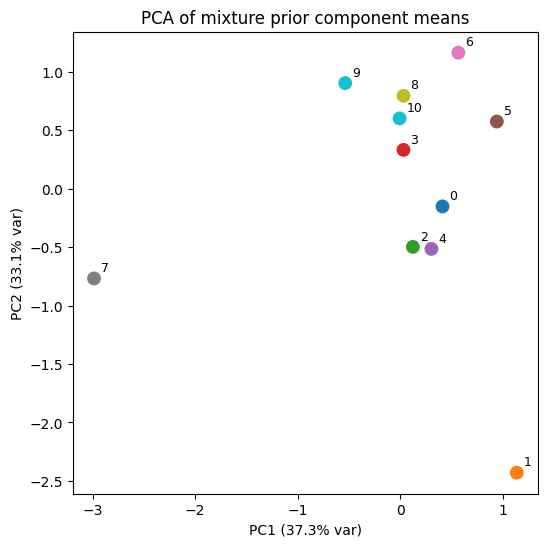

In [33]:
# pull the parameter out to a plain numpy array
means = model.module.means_active.detach().cpu().numpy()  # shape: (n_components, n_latent)

# PCA down to 2D
pca = PCA(n_components=2)
means_2d = pca.fit_transform(means)

# plot, labeling each point by its component index
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(means_2d[:, 0], means_2d[:, 1], s=80, c=np.arange(len(means)), cmap="tab10")

for i, (x, y) in enumerate(means_2d):
    ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA of mixture prior component means")
plt.show()

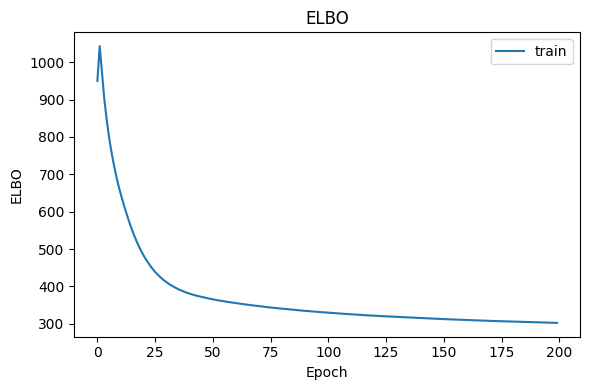

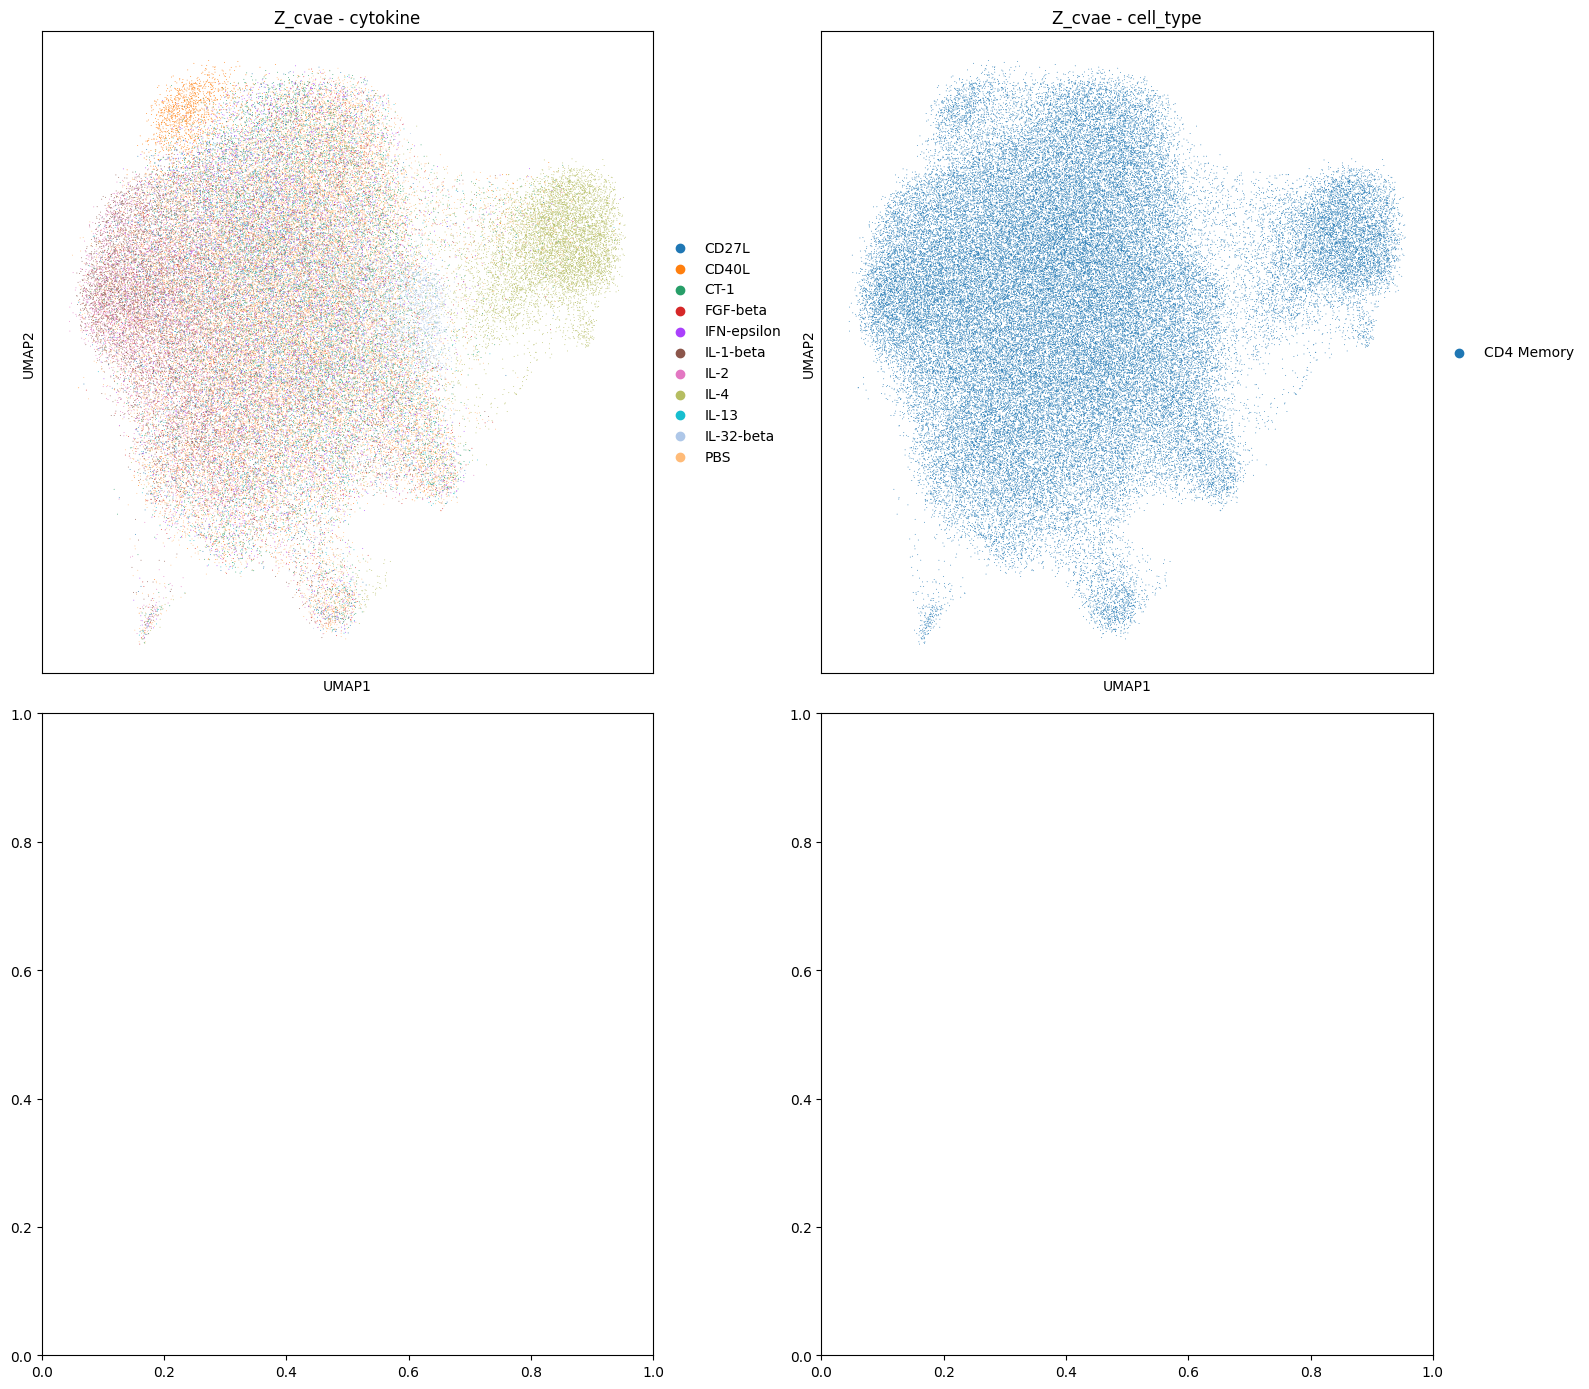

In [31]:
Z_cvae = model.get_latent_representation()
adata.obsm["Z_cvae"] = Z_cvae

hist = model.history
if "elbo_train" in hist:
    plot_metric(hist, "elbo_train", "ELBO","ELBO")


reps = ["Z_cvae"]
titles = ["Z_cvae"]

colors = [f"{labels_key}", "cell_type"]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for i, rep in enumerate(reps):
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)

    for j, color in enumerate(colors):
        sc.pl.umap(
            adata,
            color=color,
            ax=axes[i, j],
            show=False,
            title=f"{titles[i]} - {color}",
        )

plt.tight_layout()
plt.show()